# Thin film Lithium Niobate electro-optic modulator using Tidy3D

In this example, we will simulate a thin-film lithium niobate electro-optic modulator based on Pockels effect. The device is based on the work of `*Ying Li et al.*, “High-Performance Mach–Zehnder Modulator Based on Thin-Film Lithium Niobate with Low Voltage-Length Product,” *ACS Omega* 2023, 8 (10), 9644–9651.` DOI: [10.1021/acsomega.3c00310](https://pubs.acs.org/doi/10.1021/acsomega.3c00310).

We start by calculating the propagating modes of the TFLN waveguide and the coplanar (CPW) transmission line using [mode simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html).

Finally, we calculate the electro-optic overlap and predict the Vπ·L figure of merit.

You can check [here](https://docs.flexcompute.com/projects/photonforge/en/latest/examples/EO-MZM.html) the same model, along with the full chip layout integrated with a foundry PDK, using [Photonforge](https://www.flexcompute.com/photonforge/), our photonic design automation tool.

<img src="img/TFLN_EOM_Tidy3D.png" width=600 alt="Schematic of the grating coupler">

### Workflow Overview

[1.](#1) Define the thin-film lithium niobate waveguide geometry and solve for the optical TE mode using [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html).

[2.](#2) Build the CPW transmission line in the same cross-section and compute the RF mode.

[3.](#3) Normalize the RF field to 1 V across the electrodes, evaluate the electro-optic overlap, and estimate Vπ·L.

In [1]:
import numpy as np
import tidy3d as td

# RF utilities for impedance and port definitions
import tidy3d.plugins.microwave as mw
import tidy3d.plugins.smatrix as sm
from matplotlib import pyplot as plt
from tidy3d import web
from tidy3d.plugins.mode import ModeSolver

td.config.logging_level = "ERROR"

## Optical Waveguide <a name="1"></a>

In [2]:
eff_inf = 1e3

opt_wavelength = 1.55
freq_opt = td.C_0 / opt_wavelength


# Optical materials pulled from the Tidy3D library
SiO2 = td.material_library["SiO2"]["Palik_Lossless"]
LiNbO3 = td.material_library["LiNbO3"]["Zelmon1997"](1)

# Ridge geometry parameters
sidewall_angle = 15
core_thickness = 0.2
core_width = 3.0
slab_thickness = 0.2
plane_size = 8
plane_limits = (-1.5, 1.9)
plane_height = 3.4


ridge = td.Structure(
    name="ridge",
    geometry=td.Box(
        center=(0.0, 0.0, -slab_thickness / 2), size=(eff_inf, eff_inf, slab_thickness)
    ),
    medium=LiNbO3,
)

core = td.Structure(
    geometry=td.PolySlab(
        sidewall_angle=sidewall_angle * np.pi / 180,
        reference_plane="top",
        slab_bounds=[0, core_thickness],
        vertices=[
            [-eff_inf, -core_width / 2],
            [eff_inf, -core_width / 2],
            [eff_inf, core_width / 2],
            [-eff_inf, core_width / 2],
        ],
    ),
    name="core",
    medium=LiNbO3,
)


# Auto grid with 20 pts/λ
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=opt_wavelength)

sim_opt = td.Simulation(
    size=(10.0, plane_size, plane_height),
    run_time=1e-12,
    medium=SiO2,
    structures=[ridge, core],
    grid_spec=grid_spec,
)

### Creating the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) object and running the mode simulation.



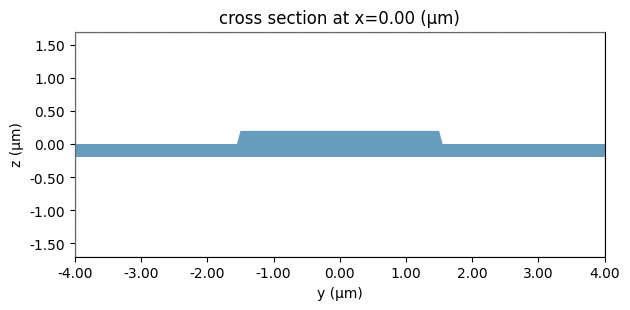

In [3]:
mode_spec = td.ModeSpec(num_modes=5)  # Request first five guided modes

plane_size = (0, sim_opt.bounding_box.size[1], sim_opt.bounding_box.size[2])
plane = sim_opt.bounding_box.updated_copy(size=plane_size)

# Configure the optical mode solver at 1.55 μm
mode_solver_opt = ModeSolver(simulation=sim_opt, freqs=[freq_opt], mode_spec=mode_spec, plane=plane)

# Quick visual check of geometry before submitting
mode_solver_opt.plot()

plt.show()

In [4]:
mode_data_opt = web.run(
    mode_solver_opt, task_name="TFLN-opt_mode", folder_name="TFLN-VPI"
)  # Submit optical mode solve

15:48:21 -03 Created task 'TFLN-opt_mode' with resource_id                      
             'mo-2f61d41e-4b95-40f6-9960-437f4e4f5141' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=621734;https://tidy3d.simulation.cloud/workbench?taskId=mo-2f61d41e-4b95-40f6-9960-437f4e4f5141\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=153209;https://tidy3d.simulation.cloud/workbench?taskId=mo-2f61d41e-4b95-40f6-9960-437f4e4f5141\taskId]8;;\]8;id=621734;https://tidy3d.simulation.cloud/workbench?taskId=mo-2f61d41e-4b95-40f6-9960-437f4e4f5141\=]8;;\]8;id=95025;https://tidy3d.simulation.cloud/workbench?taskId=mo-2f61d41e-4b95-40f6-9960-437f4e4f5141\mo]8;;\]8;id=621734;https://tidy3d.simulation.cloud/workbench?taskId=mo-2f61d41e-4b95-40f6-9960-437f4e4f5141\-2f61d41e-4b95-]8;;\
             ]8;id=621734;https://tidy3d.simulation.cloud/workbench?taskId=mo-2f61d41e-4b95-40f6-9960-437f4e4f5141\40f6-9960-437f4e4f5141']8;;\.

             Task folder: ]8;id=595758;https://tidy3d.simulation.cloud/folders/folder-8992deaf-7bd2-4439-9603-4a345bb23569\'TFLN-VPI']8;;\.

Output()

15:48:24 -03 Estimated FlexCredit cost: 0.004. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

15:48:26 -03 status = success

Output()

15:48:38 -03 loading simulation from simulation_data.hdf5

We can now visualize and inspect the optical modes.

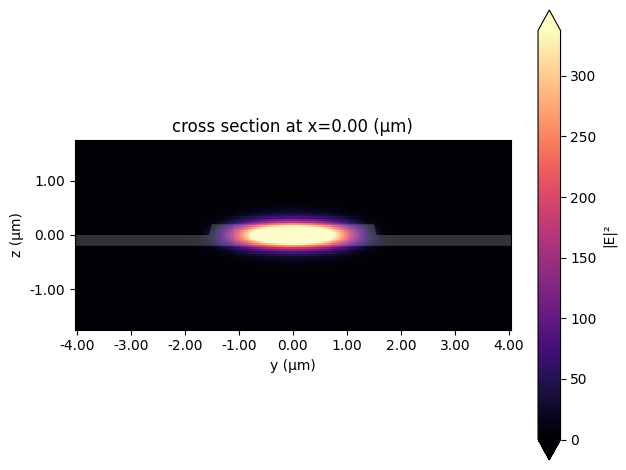

In [5]:
mode_solver_opt.plot_field("E", "abs^2", mode_index=0)  # Inspect principal optical mode
plt.show()

In [6]:
mode_data_opt.to_dataframe()  # Tabulate effective index and loss

wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
1.934145e+14 0                 1.55  1.851449    0.0          0.999711   
             1                 1.55  1.813747    0.0          0.997992   
             2                 1.55  1.762851    0.0          0.004845   
             3                 1.55  1.753301    0.0          0.978658   
             4                 1.55  1.722364    0.0          0.030296   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
1.934145e+14 0                 0.988385        0.869531   1.395676  
             1                 0.955486        0.874227   1.537450  
             2                 0.775261        0.987734   2.170106  
             3                 0.909164        0.881780   1.840836  
             4                 0.785301        0.951572   2.260011

## RF CPW Transmission Line <a name="2"></a>

Next, we define the CPW geometry and again use [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) to calculate the RF mode.

In [7]:
rf_freqs = np.linspace(1e9, 65e9, 20)  # Broadband sweep for the CPW

# RF materials

si_rf = td.Medium(permittivity=11.7)  # High-resistivity silicon substrate
sio2_rf = td.Medium(permittivity=3.9)  # Oxide buffer beneath the CPW electrodes
air_rf = td.Medium()  # Air top cladding
# RF permittivity tensor for TFLN stack
tfln_rf = td.AnisotropicMedium(
    xx=td.Medium(permittivity=44), yy=td.Medium(permittivity=27.9), zz=td.Medium(permittivity=44)
)
metal = td.LossyMetalMedium(
    frequency_range=(1e8, 1e11),
    conductivity=41,
    fit_param=td.SurfaceImpedanceFitterParam(
        max_num_poles=16,
    ),
)

# Layer stack parameters (μm)
tfln_thickness = 0.2
sio2_thickness = 7
metal_thickness = 0.9
tfln_height = 4.7 + tfln_thickness / 2  # Center of the TFLN film above the silicon

# CPW geometry (μm)
cpw_thickness = 0.9
cpw_center = sio2_thickness / 2 - cpw_thickness / 2
cpw_width = 10
cpw_gap = 4

# Ground electrode on the negative y side
cpw_left = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, -cpw_width / 2 - cpw_gap, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

# Ground electrode on the positive y side
cpw_right = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, cpw_width / 2 + cpw_gap, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, eff_inf, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

# Signal electrode between grounds
cpw_center = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -cpw_width / 2, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, cpw_width / 2, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)


# Oxide buffer volume under the CPW
sio2_slab = td.Structure(
    geometry=td.Box(center=(0, 0, 0), size=(eff_inf, eff_inf, sio2_thickness)), medium=sio2_rf
)
# Thicker TFLN slab for RF simulation
tfln_slab = td.Structure(
    geometry=td.Box(
        center=(0, 0, -sio2_thickness / 2 + tfln_height), size=(eff_inf, eff_inf, tfln_thickness)
    ),
    medium=tfln_rf,
)

# Backside silicon substrate region
si_substrate = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-eff_inf, -eff_inf, -eff_inf), rmax=(eff_inf, eff_inf, -3.5)),
    medium=si_rf,
)

# Upper air region above electrodes
air_gap = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-eff_inf, -eff_inf, 3.5), rmax=(eff_inf, eff_inf, eff_inf)),
    medium=air_rf,
)

Since the RF wavelength is much larger than the geometric features, we use a [LayerRefinementSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.LayerRefinementSpec.html) at the CPW to automatically enhance the mesh and better resolve its corners.

In [8]:
# Define RF frequency range from 1 GHz to 65 GHz
rf_freqs = np.linspace(1e9, 65e9, 20)


# Define Layer refinement spec
lr_spec = td.LayerRefinementSpec.from_structures(
    structures=[cpw_center, cpw_left, cpw_right],
    min_steps_along_axis=5,
    corner_refinement=td.GridRefinement(dl=cpw_thickness / 10, num_cells=5),
    refinement_inside_sim_only=False,
)


grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=100,
    wavelength=td.C_0 / max(rf_freqs),
    layer_refinement_specs=[lr_spec],
)

sim_rf_size = (25, 138, 150)

sim_rf = td.Simulation(
    size=sim_rf_size,
    structures=[sio2_slab, tfln_slab, si_substrate, air_gap, cpw_left, cpw_right, cpw_center],
    grid_spec=grid_spec,
    run_time=1e-12,
)

Now, we can inspect the grid.

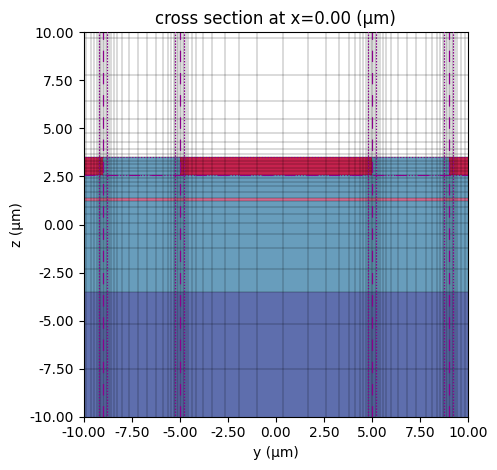

In [9]:
ax = sim_rf.plot(x=0)  # Visualize CPW layout at x=0
sim_rf.plot_grid(x=0, ax=ax)  # Overlay mesh refinement
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

plt.show()

Now, we define a [WavePort](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.smatrix.WavePort.html) object containing a [current](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.CurrentIntegralAxisAligned.html) integration path defined around the CPW signal, and a [voltage](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.VoltageIntegralAxisAligned.html) integration path from the signal to ground to calculate impedance.

In [10]:
# Integration loop encloses signal conductor
I_int = mw.CurrentIntegralAxisAligned(
    center=cpw_center.geometry.center,
    size=(
        0,
        cpw_width + cpw_gap,
        5 * cpw_thickness,
    ),
    sign="+",
)

# Line integral samples voltage across signal-ground gap
V_int = mw.VoltageIntegralAxisAligned(
    center=(0, cpw_width / 2 + cpw_gap / 2, cpw_center.geometry.center[2]),
    size=(0, cpw_gap, 0),
    sign="-",
)

# WavePort bundles the integrals into a port definition
WP1 = sm.WavePort(
    center=cpw_center.geometry.center,
    size=(0, sim_rf.size[1], sim_rf.size[2]),
    mode_spec=td.ModeSpec(target_neff=2.2),
    direction="+",
    name="WP1",
    current_integral=I_int,
    voltage_integral=V_int,
)

Finally, we can use the [WavePort](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.smatrix.WavePort.html) object to automatically configure the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) based on the RF simulation model.

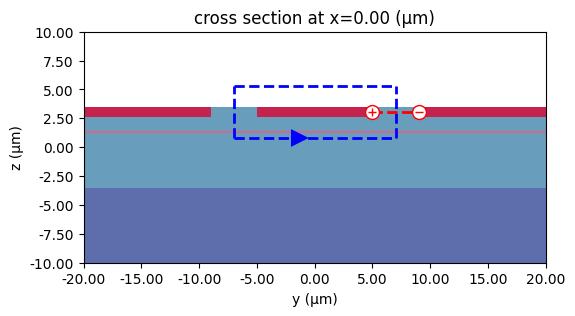

In [11]:
# Obtain mode solver from wave port
mode_solver_rf = WP1.to_mode_solver(simulation=sim_rf, freqs=rf_freqs)

# Plot V and I integration paths
fig, ax = plt.subplots(figsize=(10, 3))
mode_solver_rf.plot(ax=ax)  # Show CPW geometry defined by the port plane
I_int.plot(x=0, ax=ax)
V_int.plot(x=0, ax=ax)
ax.set_xlim(-20, 20)
ax.set_ylim(-10, 10)
plt.show()

In [12]:
mode_data_rf = web.run(mode_solver_rf, task_name="CPW mode solver", path="data/WP1_mode_data.hdf5")

15:48:39 -03 Created task 'CPW mode solver' with resource_id                    
             'mo-86904f7a-93d4-4179-aea2-7b505fd2b829' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=105546;https://tidy3d.simulation.cloud/workbench?taskId=mo-86904f7a-93d4-4179-aea2-7b505fd2b829\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=525751;https://tidy3d.simulation.cloud/workbench?taskId=mo-86904f7a-93d4-4179-aea2-7b505fd2b829\taskId]8;;\]8;id=105546;https://tidy3d.simulation.cloud/workbench?taskId=mo-86904f7a-93d4-4179-aea2-7b505fd2b829\=]8;;\]8;id=706786;https://tidy3d.simulation.cloud/workbench?taskId=mo-86904f7a-93d4-4179-aea2-7b505fd2b829\mo]8;;\]8;id=105546;https://tidy3d.simulation.cloud/workbench?taskId=mo-86904f7a-93d4-4179-aea2-7b505fd2b829\-86904f7a-93d4-]8;;\
             ]8;id=105546;https://tidy3d.simulation.cloud/workbench?taskId=mo-86904f7a-93d4-4179-aea2-7b505fd2b829\4179-aea2-7b505fd2b829']8;;\.

             Task folder: ]8;id=859771;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

15:48:42 -03 Estimated FlexCredit cost: 0.006. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

15:48:44 -03 status = success

Output()

15:48:58 -03 loading simulation from data/WP1_mode_data.hdf5

We can now use the built-in [ImpedanceCalculator](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.ImpedanceCalculator.html) to calculate and visualize the impedance results.

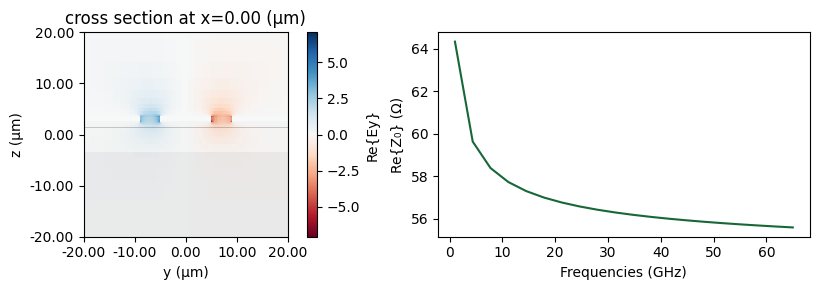

In [13]:
# Characteristic impedance from port integrals
Z0_mode = np.conjugate(
    mw.ImpedanceCalculator(voltage_integral=V_int, current_integral=I_int).compute_impedance(
        mode_data_rf
    )
).squeeze()


# Inspect RF Ey distribution
fig, ax = plt.subplots(1, 2, figsize=(9, 3), tight_layout=True)

mode_solver_rf.plot_field("Ey", "real", f=rf_freqs[0].item(), robust=False, ax=ax[0])
ax[0].set_xlim(-20, 20)
ax[0].set_ylim(-20, 20)

ax[1].plot(Z0_mode.f * 1e-9, Z0_mode.real)  # Plot real part of Z0 versus frequency
_ = ax[1].set(xlabel="Frequencies (GHz)", ylabel="Re{Z₀} (Ω)")

plt.show()

## Computation of Vπ·L <a name="3"></a>

Next, we run a similar mode simulation, this time adding the TFLN waveguides beneath the CPW gaps. We then monitor the RF fields at the waveguides and calculate the index change due to the Pockels effect.

In [14]:
# Align RF and optical coordinates
delta_z = tfln_slab.geometry.center[2] - ridge.geometry.center[2]

# Waveguides beneath right CPW gap to sample RF field
waveguide_r = [
    ridge.updated_copy(
        geometry=ridge.geometry.translated(x=0, y=cpw_width / 2 + cpw_gap / 2, z=delta_z),
        name="ridge_r",
        medium=tfln_rf,
    ),
    core.updated_copy(
        geometry=core.geometry.translated(x=0, y=-cpw_width / 2 - cpw_gap / 2, z=delta_z),
        name="core_r",
        medium=tfln_rf,
    ),
]

# Waveguides beneath left CPW gap
waveguide_l = [
    ridge.updated_copy(
        geometry=ridge.geometry.translated(x=0, y=-cpw_width / 2 - cpw_gap / 2, z=delta_z),
        name="ridge_l",
        medium=tfln_rf,
    ),
    core.updated_copy(
        geometry=core.geometry.translated(x=0, y=cpw_width / 2 + cpw_gap / 2, z=delta_z),
        name="core_l",
        medium=tfln_rf,
    ),
]

# Mesh overrides tighten resolution in core and gaps
override_region = td.MeshOverrideStructure(
    geometry=td.Box(
        size=(eff_inf, eff_inf, slab_thickness + core_thickness),
        center=(0, 0, tfln_slab.geometry.center[2] + tfln_thickness / 2),
    ),
    dl=(None, None, 0.01),
)

gap_center = cpw_center.geometry.center[1] + cpw_width / 2 + cpw_gap / 2

override_region_gap_l = td.MeshOverrideStructure(
    geometry=td.Box(size=(eff_inf, cpw_gap, eff_inf), center=(0, gap_center, 0)),
    dl=(None, 0.01, None),
)

override_region_gap_r = td.MeshOverrideStructure(
    geometry=td.Box(size=(eff_inf, cpw_gap, eff_inf), center=(0, -gap_center, 0)),
    dl=(None, 0.01, None),
)


# Updated RF simulation including optical rails
grid_spec_vpi = grid_spec.updated_copy(
    override_structures=[override_region, override_region_gap_l, override_region_gap_r]
)
sim_vpi = sim_rf.updated_copy(
    structures=[sio2_slab, si_substrate, air_gap, cpw_left, cpw_right, cpw_center]
    + waveguide_r
    + waveguide_l,
    grid_spec=grid_spec_vpi,
)

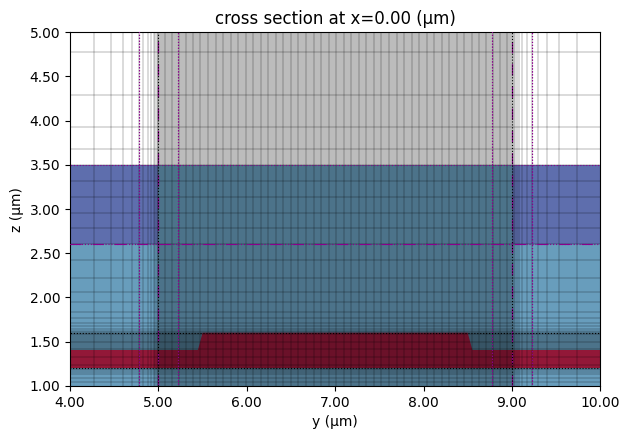

In [15]:
mzm_solver = ModeSolver(
    simulation=sim_vpi,  # RF mode solver with optical rails present
    plane=mode_solver_rf.plane,
    mode_spec=td.ModeSpec(num_modes=1, target_neff=2.2),
    freqs=rf_freqs,
)


ax = mzm_solver.plot()  # Check geometry with overrides applied
mzm_solver.plot_grid(ax=ax)  # Ensure mesh resolution near rails
ax.set_ylim(1, 5)
ax.set_xlim(4, 10)

plt.show()

In [16]:
mzm_mode_data = web.run(
    mzm_solver, task_name="MZM mode solver", path="data/MZM_mode_data.hdf5"
)  # RF fields with waveguides included

15:48:59 -03 Created task 'MZM mode solver' with resource_id                    
             'mo-52903d65-000d-403f-8f79-c68722127fc6' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=486915;https://tidy3d.simulation.cloud/workbench?taskId=mo-52903d65-000d-403f-8f79-c68722127fc6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=89770;https://tidy3d.simulation.cloud/workbench?taskId=mo-52903d65-000d-403f-8f79-c68722127fc6\taskId]8;;\]8;id=486915;https://tidy3d.simulation.cloud/workbench?taskId=mo-52903d65-000d-403f-8f79-c68722127fc6\=]8;;\]8;id=977201;https://tidy3d.simulation.cloud/workbench?taskId=mo-52903d65-000d-403f-8f79-c68722127fc6\mo]8;;\]8;id=486915;https://tidy3d.simulation.cloud/workbench?taskId=mo-52903d65-000d-403f-8f79-c68722127fc6\-52903d65-000d-]8;;\
             ]8;id=486915;https://tidy3d.simulation.cloud/workbench?taskId=mo-52903d65-000d-403f-8f79-c68722127fc6\403f-8f79-c68722127fc6']8;;\.

             Task folder: ]8;id=471469;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

15:49:02 -03 Estimated FlexCredit cost: 0.015. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

15:49:04 -03 status = success

Output()

15:49:27 -03 loading simulation from data/MZM_mode_data.hdf5

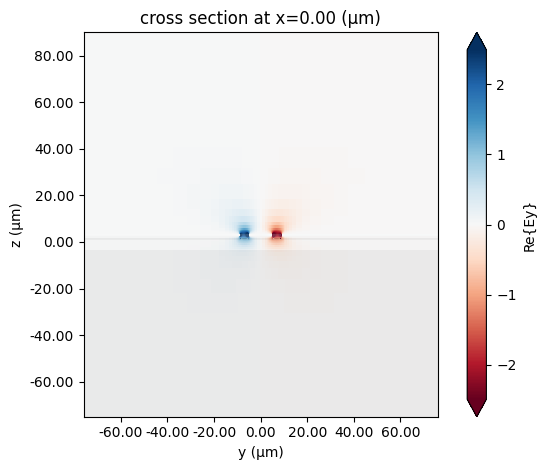

In [17]:
_ = mzm_solver.plot_field(
    "Ey", "real", f=rf_freqs[0], mode_index=0, robust=True
)  # Ey component couples to r33

plt.show()

Visualizing the results.

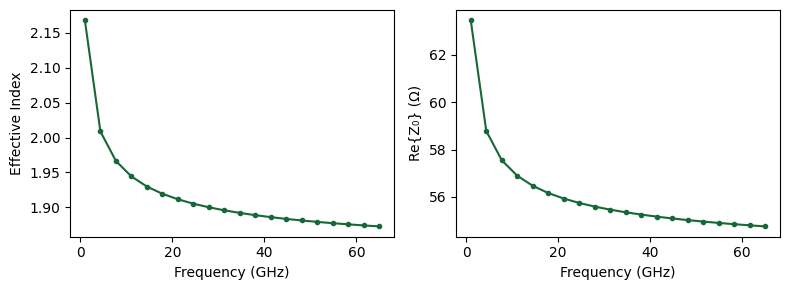

In [18]:
n_eff = mzm_solver.data.n_eff.isel(mode_index=0).values  # RF effective index with rails

# Calculate Z0
Z0_mzm = np.conjugate(  # Characteristic impedance versus frequency
    mw.ImpedanceCalculator(voltage_integral=V_int, current_integral=I_int).compute_impedance(
        mzm_mode_data
    )
).squeeze()

fig, ax = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

ax[0].plot(rf_freqs * 1e-9, n_eff, ".-")  # Dispersion of RF effective index
ax[0].set(ylabel="Effective Index", xlabel="Frequency (GHz)")

ax[1].plot(rf_freqs * 1e-9, np.real(Z0_mzm), ".-")  # Impedance trend across band
_ = ax[1].set(ylabel="Re{Z₀} (Ω)", xlabel="Frequency (GHz)")

plt.show()

To calculate the Pockels effect, we apply an electric field along the LiNbO₃ cut direction to perturb the optical medium. First, we normalize the field by the applied voltage and shift its coordinates so they align with the optical simulation, where the dielectric waveguide is centered at y = 0.

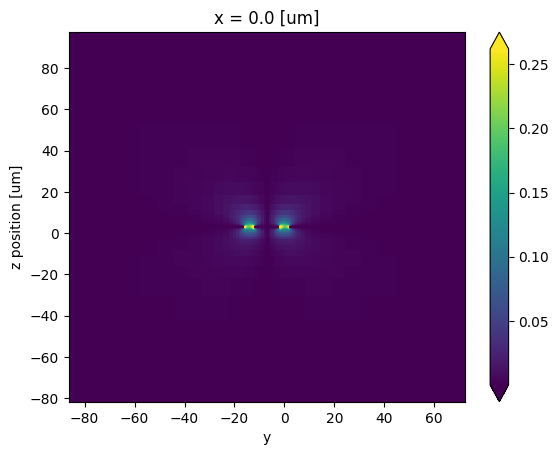

In [19]:
v0 = WP1.voltage_integral.compute_voltage(
    mzm_solver.data
)  # Extract net port voltage at each frequency
ey_norm = (
    (mzm_solver.data.Ey / v0).isel(f=0, mode_index=0, drop=True).abs
)  # Normalize Ey to 1 V drive

offset = cpw_width / 2 + cpw_gap / 2
ey_norm = ey_norm.assign_coords(y=ey_norm.y - offset)  # Shift origin so optical core sits at y=0

ey_norm.isel(x=0).transpose("z", "y").plot(robust=True)  # Field sampled through waveguide height

plt.show()

The normalized electric field is applied to the LiNbO₃ crystal along its z-axis, following the Pockels effect model:

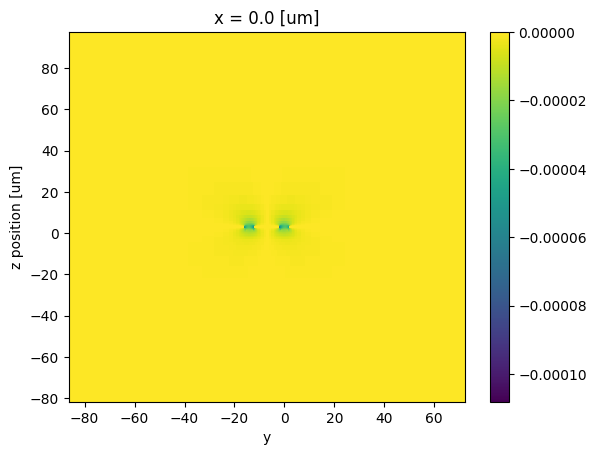

In [20]:
eps_o, eps_e, _ = (e.real for e in LiNbO3.eps_diagonal(td.C_0 / opt_wavelength))
n_e = eps_e**0.5
r33 = 30.9e-6  # μm/V electro-optic coefficient

# Index variation derived from the RF field
Δn = -0.5 * n_e**3 * r33 * ey_norm  # Voltage-induced index perturbation

# We plot the whole domain, but the perturbation will only take effect over the LiNbO₃, not everywhere
_ = Δn.isel(x=0).transpose("z", "y").plot(robust=False)

plt.show()

We can now define an auxiliary function to create the perturbed medium using a [CustomAnisotropicMedium](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.CustomAnisotropicMedium.html) object as a function of the voltage, and return a [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) object.

In [21]:
# Use a single data point for the homogeneous directions
eps_o_array = td.SpatialDataArray(np.full((1, 1, 1), eps_o), coords={"x": [0], "y": [0], "z": [0]})


# Build a voltage-dependent optical simulation
def perturbed_solver(voltage):
    perturbed_ln = td.CustomAnisotropicMedium(
        xx=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
        yy=td.CustomMedium(permittivity=(n_e + voltage * Δn) ** 2, subpixel=True),
        zz=td.CustomMedium(permittivity=eps_o_array, subpixel=True),  # Assume x and z indices fixed
    )
    perturbed_sim = sim_opt.updated_copy(
        structures=[core.updated_copy(medium=perturbed_ln), ridge.updated_copy(medium=perturbed_ln)]
    )
    ms = mode_solver_opt.updated_copy(simulation=perturbed_sim)  # Reuse optical solver settings
    return ms

Next, we create a [Batch](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.web.api.container.Batch.html) and run all mode simulations in parallel.

In [22]:
voltages = np.arange(5)  # 0–4 V sweep

sims = {str(v): perturbed_solver(v) for v in voltages}  # Label each job by voltage

batch = web.Batch(
    simulations=sims,  # Submit perturbed optical solves
    folder_name="perturbed_mode",
)

batch_data = batch.run(path_dir="batch_perturbed_mode")  # Download results when ready

Output()

15:49:36 -03 Started working on Batch containing 5 tasks.

15:49:43 -03 Maximum FlexCredit cost: 0.020 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

15:49:48 -03 Batch complete.

Output()

Finally, we can observe the variation of the waveguide mode effective index as a function of the applied voltage and calculate the Vπ·L figure of merit.

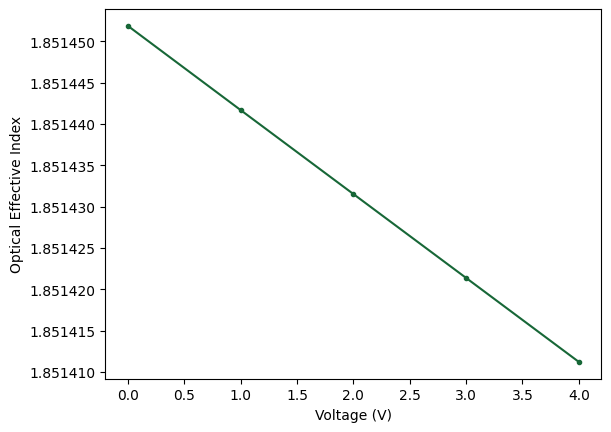

In [23]:
n_eff = [
    sim_data.n_eff.isel(mode_index=0, f=0).item() for sim_data in batch_data.values()
]  # Optical neff versus voltage

plt.plot(voltages, n_eff, ".-")  # Observe linear index tuning
_ = plt.ticklabel_format(style="plain", useOffset=False)
plt.gca().set(xlabel="Voltage (V)", ylabel="Optical Effective Index")  # Annotate axes

plt.show()

In [24]:
# Use the slope between 0 and 4 V to approximate dn_eff/dV
dneff_dV = abs(n_eff[-1] - n_eff[0]) / (voltages[-1] - voltages[0])

vpil = 0.5 * opt_wavelength / dneff_dV  # in V·μm

print(f"Vπ·L (single-drive) = {vpil * 1e-4:.2f} V·cm")  # Convert to standard units
print(f"Vπ·L (push-pull)    = {vpil * 1e-4 / 2:.2f} V·cm")  # Push-pull halves required voltage

Vπ·L (single-drive) = 7.62 V·cm
Vπ·L (push-pull)    = 3.81 V·cm
